## **Preparando o ambiente para utilizar o Pyspark**

### Instalando o Java

O Apache Spark depende de outros sistemas, portanto, antes do Spark é preciso instalar as dependências. Primeiro, deve-se instalar o java

----


In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

Em seguida, é preciso fazer o download do Spark, e, também, do hadoop, pois o Apache Spark roda sob o HDFS, em sua máquina (no caso aqui, na máquina virtual do Google Colab que você está usando.

In [ ]:
# Fazendo download
# Verificar a versão atual no link: https://spark.apache.org/downloads.html
# Data de Acesso: 01.10.2025
!wget -q https://dlcdn.apache.org/spark/spark-3.5.7/spark-3.5.7-bin-hadoop3.tgz

# Descompactando os arquivos
!tar xf spark-3.5.7-bin-hadoop3.tgz

Pronto! Agora precisamos dizer para o sistema onde encontrar o Java e o Spark, que instalamos a pouco neste ambiente.

In [ ]:
# Importando a biblioteca os
import os

# Definindo a variável de ambiente do Java
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

# Definindo a variável de ambiente do Spark
os.environ["SPARK_HOME"] = "/content/spark-3.5.7-bin-hadoop3"

A seguir, vamos precisar da biblioteca findspark que vai nos permitir importar pacotes necessários para o funcionamento do pyspark



In [ ]:
!pip install pyspark_dist_explore # Used for a histogram

In [ ]:
# instalando a findspark
!pip install -q findspark

In [ ]:
#importando a findspark
import findspark

# iniciando o findspark
findspark.init()

In [ ]:
# ------------------------------------
# Importanto as bibliotecas
# -----------------
from pyspark.sql import SparkSession
#----------
from pyspark.sql.functions import col, skewness, kurtosis # Para assimetria e Curtose
#----------
import numpy as np # Importanto Numpy
#----------
import matplotlib.pyplot as plt # Importanto Numpy
#----------
import seaborn as sns # Importando Seaborn
# -----------------

In [ ]:
# ------------------------------------
# Iniciando uma sessão do Spark
# ----
# obs:
# appName: Nome do app para a sessão
# -----------------
spark = SparkSession \
        .builder \
        .appName("Tutorial com SPARK - EPBEst2") \
        .config("spark.some.config.option", "some-value") \
        .getOrCreate()
# -----------------

Baixando os dados para serem utilizados

In [ ]:
# ------------------------------------
# Baixando os dados
# ----
#!pip install gdown
#!gdown --id 14u4dUuTSYvTOIg4nWPJGai9f8VAXFavy -O base_e-commerce_parquet.zip
# Descompactando os dados
#!unzip base_e-commerce_parquet.zip

Criar pasta userdata e fazer upload dos arquivos.

In [ ]:
# ------------------------------------
# Ler dados com extensão PARQUET
# ----
# Localização da base de dados:
# ----
# Número de linhas: 338185
# -----------------
dados = spark.read.parquet("base_e-commerce_parquet/database_compras_parquet_1M.parquet")
# -----------------

In [ ]:
# ------------------------------------
# Verificando a quantidade de linhas
# -----------------
dados.count()
# -----------------

1038185

In [ ]:
# ------------------------------------
# Verificando as colunas
# -----------------
dados.printSchema()
# -----------------

root
 |-- DsOrigem: string (nullable = true)
 |-- DsCanalVenda: string (nullable = true)
 |-- DsUnidadeNegocio: string (nullable = true)
 |-- DsTipo: string (nullable = true)
 |-- NrPedido: integer (nullable = true)
 |-- DhPedido: timestamp (nullable = true)
 |-- NrFilial: integer (nullable = true)
 |-- NrLojista: integer (nullable = true)
 |-- InMarketPlace: boolean (nullable = true)
 |-- InRetira: boolean (nullable = true)
 |-- VrVendaLiquida: double (nullable = true)
 |-- VrDescontoTotal: double (nullable = true)
 |-- VrFreteCliente: double (nullable = true)
 |-- QtItem: integer (nullable = true)
 |-- NrItemLoja: integer (nullable = true)
 |-- NrItemSite: integer (nullable = true)
 |-- DsItemSite: string (nullable = true)
 |-- NrDepartamentoSite: integer (nullable = true)
 |-- DsDepartamentoSite: string (nullable = true)
 |-- NrSetorSite: integer (nullable = true)
 |-- DsSetorSite: string (nullable = true)
 |-- NrFamiliaSite: integer (nullable = true)
 |-- DsFamiliaSite: string (nul

In [ ]:
# ------------------------------------
# Mostrando as 20 linhas da variável
# "DsCanalVenda"
# -----------------
dados.select("DsCanalVenda").show()
# -----------------

+------------+
|DsCanalVenda|
+------------+
|        SITE|
|         APP|
|         APP|
|        MOBI|
|         APP|
|        MOBI|
|         APP|
|         APP|
|        MOBI|
|         APP|
|        SITE|
|         APP|
|        MOBI|
|         APP|
|         APP|
|         APP|
|         APP|
|        SITE|
|         APP|
|        SITE|
+------------+
only showing top 20 rows



In [ ]:
dados.show(2,True)

+--------+------------+----------------+-------+---------+-------------------+--------+---------+-------------+--------+--------------+---------------+--------------+------+----------+----------+--------------------+------------------+------------------+-----------+--------------------+-------------+--------------------+-----------+-----------+--------------------+
|DsOrigem|DsCanalVenda|DsUnidadeNegocio| DsTipo| NrPedido|           DhPedido|NrFilial|NrLojista|InMarketPlace|InRetira|VrVendaLiquida|VrDescontoTotal|VrFreteCliente|QtItem|NrItemLoja|NrItemSite|          DsItemSite|NrDepartamentoSite|DsDepartamentoSite|NrSetorSite|         DsSetorSite|NrFamiliaSite|       DsFamiliaSite|NrMarcaSite|DsMarcaSite|          DsSingleId|
+--------+------------+----------------+-------+---------+-------------------+--------+---------+-------------+--------+--------------+---------------+--------------+------+----------+----------+--------------------+------------------+------------------+----------

In [ ]:
# Ordenando pela data
df_ordenado = dados.orderBy(col("DhPedido").desc())
df_ordenado.show(2,True)

+--------+------------+----------------+-------+---------+-------------------+--------+---------+-------------+--------+--------------+---------------+--------------+------+----------+----------+--------------------+------------------+--------------------+-----------+-----------+-------------+------------------+-----------+-----------+--------------------+
|DsOrigem|DsCanalVenda|DsUnidadeNegocio| DsTipo| NrPedido|           DhPedido|NrFilial|NrLojista|InMarketPlace|InRetira|VrVendaLiquida|VrDescontoTotal|VrFreteCliente|QtItem|NrItemLoja|NrItemSite|          DsItemSite|NrDepartamentoSite|  DsDepartamentoSite|NrSetorSite|DsSetorSite|NrFamiliaSite|     DsFamiliaSite|NrMarcaSite|DsMarcaSite|          DsSingleId|
+--------+------------+----------------+-------+---------+-------------------+--------+---------+-------------+--------+--------------+---------------+--------------+------+----------+----------+--------------------+------------------+--------------------+-----------+-----------+--

### Dividir a base em treino e predição

In [ ]:
# Separando o data.frame dados em dois data.frames

# Separando as 100 linhas mais recentes
dados_pred = df_ordenado.limit(100)

# Criar DataFrame com o restante
dados_treino = df_ordenado.subtract(dados_pred)  # remove as 100 linhas do df original

---
## Market Basket Analysis usando PySpark
---

In [ ]:
qtde_compras = dados_treino.groupBy("DsSingleId").count()
qtde_compras.show(5)

+--------------------+-----+
|          DsSingleId|count|
+--------------------+-----+
|56d879ba-fc19-11e...|    7|
|aa730264-fc16-11e...|  271|
|5b1abf9c-fc19-11e...|   14|
|58865be2-fc19-11e...|    8|
|561c5852-fc19-11e...|   22|
+--------------------+-----+
only showing top 5 rows



(array([9.5998e+04, 1.0854e+04, 2.1190e+03, 5.7600e+02, 2.2300e+02,
        9.4000e+01, 4.2000e+01, 2.0000e+01, 2.1000e+01, 1.2000e+01,
        1.3000e+01, 4.0000e+00, 4.0000e+00, 3.0000e+00, 1.0000e+00,
        2.0000e+00, 3.0000e+00, 1.0000e+00, 3.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([  1. ,  17.5,  34. ,  50.5,  67. ,  83.5, 100. , 116.5, 133. ,
        149.5, 166. , 182.5, 199. , 215.5, 232. , 248.5, 265. , 281.5,
        298. , 314.5, 331. , 347.5, 364. , 380.5, 397. , 413.5, 430. ,
        446.5, 463. , 479.5, 496. ]),
 <BarContainer object of 30 artists>)

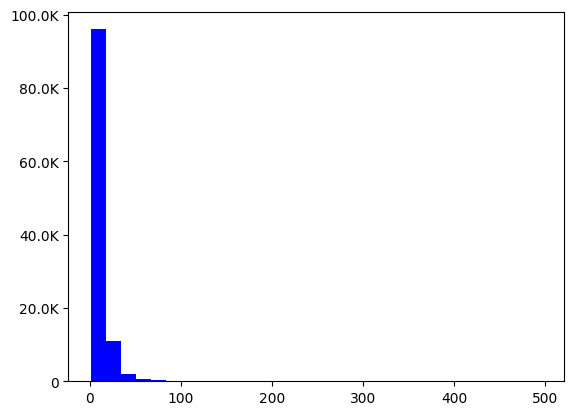

In [ ]:
from pyspark_dist_explore import hist
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
hist(ax, qtde_compras.select('count'), bins = 30, color=['blue'])

### Implementação do FPGrowth

In [ ]:
from pyspark.sql import functions as f, SparkSession, Column
from pyspark.sql.functions import collect_list, array_repeat, concat, col

# Agrupar produtos por DsSingleId
dados_compras_agg = dados_treino.groupBy("DsSingleId").agg(collect_list("DsItemSite").alias("compras"))

# Visualizando o Schema()
dados_compras_agg.printSchema()

root
 |-- DsSingleId: string (nullable = true)
 |-- compras: array (nullable = false)
 |    |-- element: string (containsNull = false)



In [ ]:
# Visualizando 3 linhas do data.frame
dados_compras_agg.show(3, False)

+------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|DsSingleId                          |compras                                                                                                                                                                                                    

In [ ]:
# Removendo valores nulos
df_aggregated = dados_compras_agg.select("DsSingleId", f.array_except("compras", f.array(f.lit(None))).alias("compras"))
df_aggregated.show(3, False)

+------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|DsSingleId                          |compras                                                                                                                                                                                                    

**Hiperparâmetros**
Os hiperparâmetros usados no FPGrowth são suporte mínimo, confiança mínima

* **minSupport** – O suporte mínimo de um item para que ele seja considerado em um conjunto frequente de itens.
* **minConfidence** – A confiança mínima para gerar uma regra de associação a partir de um conjunto de itens.

In [ ]:
# Executando o FPGrowth e criando o modelo
from pyspark.ml.fpm import FPGrowth

#fp = FPGrowth(minSupport=0.00005, minConfidence=0.0001, itemsCol='compras', predictionCol='prediction')
fp = FPGrowth(minSupport=0.00008, minConfidence=0.05, itemsCol='compras', predictionCol='prediction')

model = fp.fit(df_aggregated)

In [ ]:
# Veja um subconjunto do conjunto de itens frequentes
model.freqItemsets.show(10, False)

+-------------------------------------------------------------------------------------------------------------------------------------------+----+
|items                                                                                                                                      |freq|
+-------------------------------------------------------------------------------------------------------------------------------------------+----+
|[Panela Elétrica de Arroz EOS 10 Xícaras Inox Branca com Tampa de Vidro Clear Glass EPA10BI 110V 110V]                                     |13  |
|[Caixa de Som Portátil Mondial MCO-08 com Bluetooth, Entrada USB, Rádio FM e Flash Light - 100W]                                           |34  |
|[Coifa Parede Slim Nardelli Vidro Curvo Inox 60cm 127V]                                                                                    |15  |
|[Tigela de Vidro Americano 4210 150ml 12 Peças Cores Sortidas - Nadir]                                               

In [ ]:
# Use o filtro para visualizar apenas as regras de associação com a maior confiança.
#model.associationRules.filter(model.associationRules.confidence>0.15).show(20, False)

### Vamos criar uma previsão com base nas regras de associação geradas

In [ ]:
# Predict
dados_pred_sel = dados_pred.select("DsSingleId", "DsItemSite")
dados_pred_sel_compras = dados_pred_sel.withColumnRenamed("DsItemSite","compras")
dados_pred_aggregated = dados_pred_sel_compras.groupBy("DsSingleId").agg(
    f.collect_list("compras").alias("compras")
)

In [ ]:
#dados_pred_aggregated.show()

In [ ]:
model.transform(dados_pred_aggregated).show(20, True)

+--------------------+--------------------+--------------------+
|          DsSingleId|             compras|          prediction|
+--------------------+--------------------+--------------------+
|4ed72d92-50af-11e...|[Panela de Pressã...|                  []|
|578db190-fc19-11e...|[Panela de Pressã...|                  []|
|a5f83e32-fc18-11e...|[Panela de Pressã...|                  []|
|286f4d70-fc18-11e...|[Refrigerador Bra...|[Smartphone Samsu...|
|a526a0f2-fc18-11e...|[Cozinha Bartira ...|[Smartphone Samsu...|
|a62dcf16-fc18-11e...|[Refrigerador Bra...|[Smartphone Samsu...|
|b2399d5a-fc16-11e...|[Refrigerador Bra...|[Smartphone Samsu...|
|59aaad7a-fc19-11e...|[Cozinha Bartira ...|[Smartphone Samsu...|
|34f39042-0b8a-11e...|[Cozinha Bartira ...|[Smartphone Samsu...|
|a796d9bc-fc16-11e...|[Refrigerador Bra...|[Smartphone Samsu...|
|a6e7c83a-fc18-11e...|[Buffet Viero Móv...|                  []|
|56051142-fc19-11e...|[Smartphone Motor...|                  []|
|a51c16a0-fc18-11e...|[Sm